# Exploratory Data Analysis & Vulnerability Analysis

## Objective

This notebook explores patterns of financial exclusion using the governed dataset created in Notebook 02.

The analysis focuses on:
- overall exclusion prevalence
- demographic vulnerability
- rural and youth exclusion
- county-level inequality
- education and household structure
- early predictor discovery

This notebook also benchmarks selected findings against the 2024 FinAccess Household Survey Report, which reported that 9.9% of Kenyan adults remained financially excluded and that rural youth formed 45.5% of the excluded population. :contentReference[oaicite:0]{index=0}

## Environment Setup

This section imports the required libraries, defines project paths, and prepares figure-saving directories for reproducible EDA.

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [3]:
BASE_DIR = Path("..")

PROCESSED_DIR = BASE_DIR / "Data" / "Processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load Governed Modeling Dataset

The processed dataset from Notebook 02 is loaded for exploratory analysis.

This ensures that the EDA uses the leakage-governed and sparsity-filtered dataset rather than the raw survey data.

In [4]:
model_df = pd.read_csv(
    PROCESSED_DIR / "financial_inclusion_model_df.csv"
)

model_df.head()

<ipython-input-4-c2e70f92b624>:1: DtypeWarning: Columns (18,19,20,21,22,23,68,71,74,77,80,83,86,89,92,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,264,265,266,268,269,274,277,278,279,281,284,287,742,763,767,768,769,894,932,933,934,935,1057,1058,1147,1179,1180,1181,1182,1183,1206,1207,1208,1209,1210) have mixed types. Specify dtype option on import or set low_memory=False.
  model_df = pd.read_csv(


,County,ClusterNo,HHNo,location_type,A9i,gender,A14v,A14vi,A15,A17,...,formal_banked2022,NHIF_health_insurance,NHIF_ONLY,Nomedical,NHIFMedical_Cat,adults,financially_excluded,is_youth,is_rural,rural_youth
0,Trans Nzoia,10226038,1048,Rural,Access granted,Female,1,1,Swahili,0,...,No,Yes,NaN,NaN,Users of NHIF + medical insurance (C1_42 and C...,1 adult Household,0,0,1,0
1,Busia,10240034,1080,Rural,Access granted,Female,4,2,English,0,...,Yes,Yes,1.0,NaN,"Users of NHIF only, with no medical insurance",>1 adult Household,0,0,1,0
2,Machakos,10216062,1013,Rural,Access granted,Male,1,1,Swahili,0,...,No,Yes,1.0,NaN,"Users of NHIF only, with no medical insurance",1 adult Household,1,0,1,0
3,Kisumu,10242078,1026,Rural,Access granted,Male,5,4,Swahili,0,...,Yes,No,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household,0,1,1,1
4,Nyeri,10219138,1019,Urban,Access granted,Male,3,2,Other(specify),0,...,Yes,No,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household,0,0,0,0


## Mixed-Type Warning Interpretation

Some survey variables contain mixed data types due to:
- survey routing logic
- categorical/numeric combinations
- partially populated response structures

This behavior is common in large household survey systems and does not prevent exploratory analysis.

Variables will later be evaluated individually during:
- feature selection
- modeling
- explainability analysis

## Initial Dataset Validation

Before analysis begins, the dataset is validated to confirm:
- successful loading
- expected shape
- target availability
- presence of engineered vulnerability features

In [6]:
print("Dataset shape:", model_df.shape)

print("\nTarget distribution:")
print(model_df["financially_excluded"].value_counts())

print("\nKey engineered features:")
print([
    col for col in ["age", "is_youth", "is_rural", "rural_youth"]
    if col in model_df.columns
])

print("\nFirst 20 columns:")
print(model_df.columns[:20].tolist())

Dataset shape: (22024, 1529)

Target distribution:
financially_excluded
0    17430
1     4594
Name: count, dtype: int64

Key engineered features:
['is_youth', 'is_rural', 'rural_youth']

First 20 columns:
['County', 'ClusterNo', 'HHNo', 'location_type', 'A9i', 'gender', 'A14v', 'A14vi', 'A15', 'A17', 'A18', 'raw_age', 'A20', 'education_level', 'marital_status', 'A23', 'A24', 'A25', 'A26__1', 'A26__2']


## Initial Validation Observations

The dataset loaded successfully and preserved:
- governance filtering decisions
- engineered vulnerability indicators
- target availability

The target distribution reveals a moderate class imbalance, with financially excluded respondents representing a minority subgroup.

This imbalance will later influence:
- model evaluation strategy
- fairness analysis
- metric interpretation
- predictive calibration decisions

# Target Distribution Analysis

This section examines the prevalence of financial exclusion within the governed analytical dataset.

The analysis helps:
- quantify exclusion prevalence
- assess class imbalance
- benchmark findings against the 2024 FinAccess report
- establish the foundation for downstream vulnerability analysis

In [7]:
# Calculate exclusion percentages

target_pct = (
    model_df["financially_excluded"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_pct

financially_excluded
0    79.14
1    20.86
Name: proportion, dtype: float64

## Exclusion Prevalence Observations

The processed analytical dataset indicates that approximately 20.86% of respondents are financially excluded.

This is substantially higher than the 9.9% national exclusion estimate reported in the 2024 FinAccess Household Survey Report. :contentReference[oaicite:1]{index=1}

Several factors may contribute to this difference:
- the use of unweighted respondent-level analysis
- differences in target engineering methodology
- preprocessing and governance filtering decisions
- sampling structure within the analytical subset

Despite the difference in prevalence, the dataset remains valuable for:
- subgroup vulnerability analysis
- structural inequality analysis
- predictive modeling
- explainable AI interpretation

## Financial Exclusion Distribution

The target distribution is visualized to:
- illustrate exclusion prevalence
- communicate class imbalance
- support stakeholder interpretation
- establish the foundation for downstream subgroup analysis

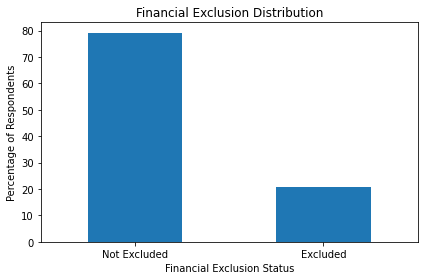

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

target_pct.sort_index().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Financial Exclusion Distribution")
ax.set_xlabel("Financial Exclusion Status")
ax.set_ylabel("Percentage of Respondents")

ax.set_xticklabels(
    ["Not Excluded", "Excluded"],
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Target Distribution Interpretation

The visualization confirms that financially excluded respondents represent a minority subgroup within the analytical dataset.

This creates a moderately imbalanced classification problem that will later influence:
- model evaluation strategy
- fairness assessment
- metric selection
- predictive calibration

Despite being the minority class, financially excluded respondents represent a socially and economically important subgroup requiring targeted analytical attention.

The observed exclusion prevalence exceeds the national benchmark reported in the 2024 FinAccess report, suggesting possible differences related to:
- unweighted respondent-level analysis
- target engineering methodology
- preprocessing decisions
- analytical sample structure

# Gender Vulnerability Analysis

This section investigates whether financial exclusion patterns differ across gender groups.

Gender-based financial inequality remains an important policy concern in financial inclusion research because access barriers may differ across:
- economic participation
- digital access
- financial autonomy
- employment structures

The analysis helps identify whether exclusion patterns disproportionately affect specific gender groups.

## Gender Distribution

The gender distribution is examined to:
- understand subgroup representation
- validate demographic balance
- support downstream exclusion analysis

In [9]:
gender_counts = model_df["gender"].value_counts()

gender_pct = (
    model_df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(gender_counts)
print("\n")
print(gender_pct)

gender
Male      12998
Female     9026
Name: count, dtype: int64


gender
Male      59.02
Female    40.98
Name: proportion, dtype: float64


## Gender Distribution Observations

The analytical dataset contains a higher proportion of male respondents relative to female respondents.

This demographic imbalance is important because subgroup representation may later influence:
- predictive modeling behavior
- fairness evaluation
- subgroup explainability
- interpretation of exclusion disparities

The imbalance does not necessarily indicate survey bias, but it highlights the importance of careful subgroup analysis throughout the project.

## Gender Representation Visualization

The gender distribution is visualized to:
- communicate subgroup representation
- support stakeholder interpretation
- establish context for gender-based exclusion analysis

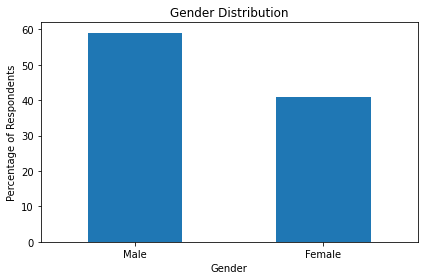

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

gender_pct.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Gender Distribution")
ax.set_xlabel("Gender")
ax.set_ylabel("Percentage of Respondents")

ax.set_xticklabels(
    gender_pct.index,
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gender Representation Interpretation

The visualization confirms that male respondents constitute the majority subgroup within the analytical dataset.

This demographic structure is important for downstream analysis because subgroup representation may influence:
- predictive behavior
- fairness outcomes
- exclusion interpretation
- subgroup explainability

The imbalance also reinforces the importance of evaluating exclusion patterns separately across gender groups rather than relying solely on aggregate statistics.

## Financial Exclusion by Gender

This section evaluates whether financial exclusion rates differ across gender groups.

Understanding subgroup disparities is important because exclusion patterns may reflect:
- structural inequality
- unequal financial access
- employment differences
- digital access gaps
- social and economic barriers

The analysis helps identify whether exclusion disproportionately affects specific gender groups.

In [11]:
gender_exclusion = pd.crosstab(
    model_df["gender"],
    model_df["financially_excluded"],
    normalize="index"
).mul(100).round(2)

gender_exclusion

financially_excluded,0,1
gender,,
Female,76.24,23.76
Male,81.16,18.84


## Gender Exclusion Observations

The analysis reveals that female respondents experience higher financial exclusion rates relative to male respondents within the analytical dataset.

This suggests the possible presence of:
- structural financial inequality
- unequal access barriers
- demographic vulnerability patterns

The observed disparity is socially meaningful and may reflect differences related to:
- employment participation
- financial autonomy
- digital access
- formal financial engagement

Because gender represents a sensitive demographic attribute, its role in predictive modeling will later require careful fairness evaluation and explainability analysis.

## Gender-Based Exclusion Visualization

Financial exclusion rates are visualized across gender groups to:
- communicate subgroup disparities
- support stakeholder interpretation
- identify structural inequality patterns
- prepare for fairness-oriented analysis

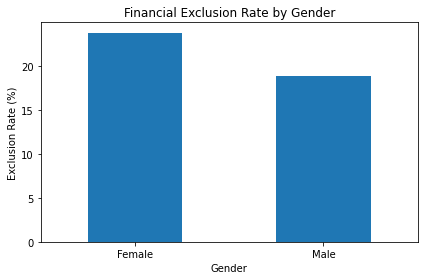

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

gender_exclusion[1].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Financial Exclusion Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Exclusion Rate (%)")

ax.set_xticklabels(
    gender_exclusion.index,
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_gender_exclusion_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gender Vulnerability Interpretation

The visualization confirms that female respondents experience higher exclusion rates relative to male respondents within the analytical dataset.

This pattern suggests that gender-related structural barriers may influence financial inclusion outcomes.

The observed disparity reinforces the importance of:
- subgroup analysis
- fairness-aware modeling
- explainable AI interpretation
- policy-oriented intervention analysis

The finding may also support targeted inclusion strategies focused on vulnerable demographic populations.

# Rural Vulnerability Analysis

This section investigates whether financial exclusion differs between:
- rural populations
and
- urban populations

Geographic inequality is an important financial inclusion concern because rural populations may experience:
- reduced banking infrastructure
- transportation barriers
- weaker digital connectivity
- lower formal financial access

The 2024 FinAccess report also highlighted the continued vulnerability of rural populations and rural youth within Kenya’s financial inclusion landscape. :contentReference[oaicite:1]{index=1}

## Settlement-Type Distribution

The settlement-type distribution is examined to:
- understand geographic representation
- validate subgroup balance
- establish context for rural vulnerability analysis

In [13]:
location_counts = model_df["location_type"].value_counts()

location_pct = (
    model_df["location_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(location_counts)

print("\n")

print(location_pct)

location_type
Rural    14455
Urban     7569
Name: count, dtype: int64


location_type
Rural    65.63
Urban    34.37
Name: proportion, dtype: float64


## Settlement Distribution Observations

The analytical dataset is predominantly rural, with rural respondents representing approximately two-thirds of the population.

This geographic structure is important because financial inclusion outcomes are often strongly influenced by:
- infrastructure availability
- banking proximity
- transportation access
- digital connectivity

The strong rural representation aligns with the broader policy relevance of rural financial vulnerability highlighted in the 2024 FinAccess report. :contentReference[oaicite:1]{index=1}

## Geographic Representation Visualization

The settlement-type distribution is visualized to:
- communicate geographic representation
- support stakeholder interpretation
- establish context for exclusion-risk analysis

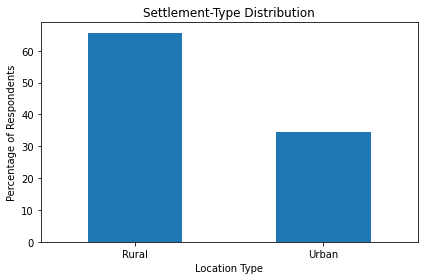

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

location_pct.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Settlement-Type Distribution")
ax.set_xlabel("Location Type")
ax.set_ylabel("Percentage of Respondents")

ax.set_xticklabels(
    location_pct.index,
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_location_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Geographic Representation Interpretation

The visualization confirms that rural respondents represent the dominant subgroup within the analytical dataset.

This geographic imbalance is analytically important because rural populations may experience structural disadvantages related to:
- infrastructure access
- financial proximity
- digital inclusion
- institutional availability

The strong rural representation also reinforces the importance of evaluating exclusion disparities separately across settlement types.

## Financial Exclusion by Settlement Type

This section evaluates whether financial exclusion rates differ between:
- rural populations
and
- urban populations

The analysis helps identify whether geographic location contributes to:
- structural financial vulnerability
- unequal access patterns
- infrastructure-related exclusion disparities

Understanding these patterns is important for:
- policy targeting
- subgroup vulnerability analysis
- explainable AI interpretation
- financial inclusion strategy development

In [15]:
location_exclusion = pd.crosstab(
    model_df["location_type"],
    model_df["financially_excluded"],
    normalize="index"
).mul(100).round(2)

location_exclusion

financially_excluded,0,1
location_type,,
Rural,74.92,25.08
Urban,87.21,12.79


## Geographic Exclusion Observations

The analysis reveals a substantial geographic disparity in financial exclusion outcomes.

Rural respondents experience significantly higher exclusion rates relative to urban respondents, suggesting the presence of:
- infrastructure-related barriers
- reduced banking proximity
- weaker digital connectivity
- structural access inequality

The observed disparity strongly aligns with broader financial inclusion concerns highlighted in the 2024 FinAccess report, particularly regarding rural vulnerability and unequal access patterns. :contentReference[oaicite:1]{index=1}

The findings also provide empirical support for the engineered rural vulnerability indicators created during preprocessing.

## Geographic Exclusion Visualization

Financial exclusion rates are visualized across settlement types to:
- communicate geographic inequality
- support stakeholder interpretation
- identify structural vulnerability patterns
- benchmark rural exclusion disparities

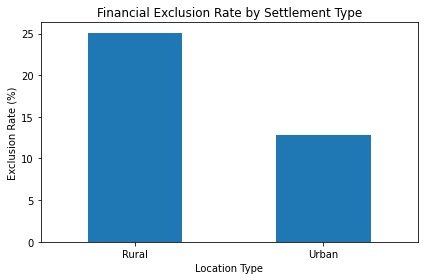

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

location_exclusion[1].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Financial Exclusion Rate by Settlement Type")
ax.set_xlabel("Location Type")
ax.set_ylabel("Exclusion Rate (%)")

ax.set_xticklabels(
    location_exclusion.index,
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_location_exclusion_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Geographic Vulnerability Interpretation

The visualization confirms that rural populations experience substantially higher exclusion rates relative to urban populations.

The magnitude of the disparity suggests that geographic location plays an important role in financial inclusion outcomes.

The findings reinforce the importance of:
- rural-focused inclusion strategies
- infrastructure-sensitive policy interventions
- digital-access expansion
- subgroup-aware predictive modeling

The results also support the analytical importance of the engineered `is_rural` and `rural_youth` indicators.

# Rural Youth Vulnerability Analysis

This section investigates financial exclusion patterns among respondents classified as:
- rural
and
- youth

The 2024 FinAccess report highlighted rural youth as one of the most financially vulnerable population groups in Kenya. :contentReference[oaicite:1]{index=1}

The analysis helps determine whether compounded structural vulnerability may exist among respondents simultaneously exposed to:
- geographic disadvantage
- demographic vulnerability

## Rural Youth Representation

The rural-youth subgroup distribution is examined to:
- quantify subgroup representation
- assess structural vulnerability exposure
- establish context for exclusion-risk analysis

In [17]:
rural_youth_counts = model_df["rural_youth"].value_counts()

rural_youth_pct = (
    model_df["rural_youth"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(rural_youth_counts)

print("\n")

print(rural_youth_pct)

rural_youth
0    15757
1     6267
Name: count, dtype: int64


rural_youth
0    71.54
1    28.46
Name: proportion, dtype: float64


## Rural Youth Representation Observations

The rural-youth subgroup represents a substantial portion of the analytical population.

This is important because rural youth populations may simultaneously experience:
- demographic vulnerability
- geographic disadvantage
- reduced institutional access
- weaker economic participation opportunities

The strong representation of this subgroup reinforces the policy relevance of evaluating compounded structural vulnerability patterns within the dataset.

## Financial Exclusion by Rural Youth Status

This section evaluates whether respondents classified as rural youth experience elevated exclusion risk relative to the broader population.

The analysis investigates whether compounded demographic and geographic vulnerability contributes to unequal financial inclusion outcomes.

In [18]:
rural_youth_exclusion = pd.crosstab(
    model_df["rural_youth"],
    model_df["financially_excluded"],
    normalize="index"
).mul(100).round(2)

rural_youth_exclusion

financially_excluded,0,1
rural_youth,,
0,83.82,16.18
1,67.37,32.63


## Rural Youth Vulnerability Observations

The analysis reveals a substantial compounded vulnerability pattern among rural youth respondents.

Rural youth experience significantly higher exclusion rates relative to the broader population, suggesting the presence of:
- structural inequality
- geographic disadvantage
- reduced institutional access
- demographic vulnerability

The observed disparity strongly aligns with findings from the 2024 FinAccess report, which highlighted rural youth as one of the most financially vulnerable population groups in Kenya. :contentReference[oaicite:1]{index=1}

The results provide strong empirical support for the engineered `rural_youth` feature and reinforce its analytical importance for:
- predictive modeling
- explainability analysis
- subgroup vulnerability assessment
- policy-oriented intervention planning

## Rural Youth Exclusion Visualization

Financial exclusion rates are visualized across rural-youth subgroup categories to:
- communicate compounded vulnerability
- support stakeholder interpretation
- identify high-risk populations
- benchmark structural inequality patterns

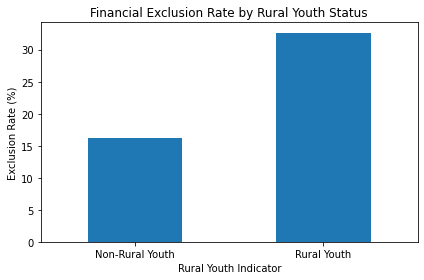

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

rural_youth_exclusion[1].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Financial Exclusion Rate by Rural Youth Status")
ax.set_xlabel("Rural Youth Indicator")
ax.set_ylabel("Exclusion Rate (%)")

ax.set_xticklabels(
    ["Non-Rural Youth", "Rural Youth"],
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_rural_youth_exclusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Rural Youth Vulnerability Interpretation

The visualization confirms that rural youth respondents experience substantially higher exclusion rates relative to the broader population.

The magnitude of the disparity suggests the presence of compounded structural vulnerability associated with:
- demographic disadvantage
- geographic inequality
- reduced financial access opportunities

The findings strongly align with national financial inclusion concerns highlighted in the 2024 FinAccess report and reinforce the importance of:
- subgroup-aware analysis
- fairness-sensitive modeling
- targeted intervention strategies
- explainable AI interpretation

# Education Vulnerability Analysis

This section investigates whether financial exclusion patterns differ across education levels.

Education may influence financial inclusion outcomes through:
- financial literacy
- employment opportunities
- digital capability
- institutional awareness
- formal financial participation

The analysis helps identify whether lower educational attainment is associated with elevated exclusion vulnerability.

## Education-Level Distribution

The education-level distribution is examined to:
- understand subgroup representation
- assess educational diversity
- establish context for exclusion-risk analysis

In [20]:
education_counts = (
    model_df["education_level"]
    .value_counts(dropna=False)
)

education_pct = (
    model_df["education_level"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

print(education_counts)

print("\n")

print(education_pct)

education_level
"Some primary "                                        4639
"Primary completed"                                    4207
"None "                                                3987
"Secondary completed "                                 3914
"Some secondary"                                       2717
Completed technical training after secondary school    1155
"University completed "                                 662
Some technical training after secondary school          402
Some university                                         316
"Other (Specify) "                                       20
"Don't know (DO NOT READ OUT)"                            3
"Refused to Answer (DO NOT READ OUT)"                     2
Name: count, dtype: int64


education_level
"Some primary "                                        21.06
"Primary completed"                                    19.10
"None "                                                18.10
"Secondary completed "               

## Education Distribution Observations

The analytical dataset is dominated by respondents with lower educational attainment, particularly:
- some primary education
- completed primary education
- no formal education

This is analytically important because education frequently influences:
- financial literacy
- formal financial participation
- digital capability
- employment opportunities
- institutional access

The education variable also contains formatting inconsistencies and small sparse categories that may require standardization before advanced modeling workflows.

## Education Label Standardization

Education categories are standardized to:
- remove quotation marks
- remove spacing inconsistencies
- improve readability
- support downstream visualization and modeling

In [21]:
# Clean education labels

model_df["education_level"] = (
    model_df["education_level"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

model_df["education_level"].value_counts()

education_level
Some primary                                           4639
Primary completed                                      4207
None                                                   3987
Secondary completed                                    3914
Some secondary                                         2717
Completed technical training after secondary school    1155
University completed                                    662
Some technical training after secondary school          402
Some university                                         316
Other (Specify)                                          20
Don't know (DO NOT READ OUT)                              3
Refused to Answer (DO NOT READ OUT)                       2
Name: count, dtype: int64

## Education Label Standardization Observations

The education categories were successfully standardized to improve:
- readability
- categorical consistency
- visualization quality
- stakeholder interpretation

The cleaned categories now provide a clearer educational progression structure suitable for:
- subgroup analysis
- vulnerability assessment
- predictive modeling
- explainability workflows

## Education-Level Visualization

The education distribution is visualized to:
- communicate educational composition
- identify dominant education groups
- support socioeconomic vulnerability analysis
- establish context for exclusion-risk interpretation

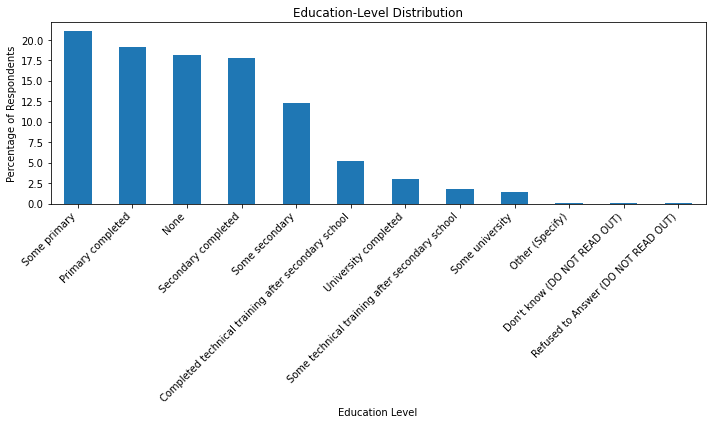

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

(
    model_df["education_level"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .plot(kind="bar", ax=ax)
)

ax.set_title("Education-Level Distribution")
ax.set_xlabel("Education Level")
ax.set_ylabel("Percentage of Respondents")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_education_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Financial Exclusion by Education Level

This section evaluates whether financial exclusion rates differ across education groups.

Education may influence financial inclusion outcomes through:
- financial literacy
- employment opportunities
- digital capability
- institutional awareness
- formal financial participation

The analysis helps identify whether lower educational attainment is associated with elevated exclusion vulnerability.

In [23]:
education_exclusion = pd.crosstab(
    model_df["education_level"],
    model_df["financially_excluded"],
    normalize="index"
).mul(100).round(2)

education_exclusion

financially_excluded,0,1
education_level,,
Completed technical training after secondary school,98.27,1.73
Don't know (DO NOT READ OUT),100.00,0.00
None,64.23,35.77
Other (Specify),85.00,15.00
Primary completed,84.88,15.12
Refused to Answer (DO NOT READ OUT),100.00,0.00
Secondary completed,91.11,8.89
Some primary,75.10,24.90
Some secondary,63.89,36.11


## Education Vulnerability Observations

The analysis reveals a strong education-related exclusion gradient within the analytical dataset.

Lower educational attainment is associated with substantially higher exclusion rates, while respondents with technical or university-level education experience extremely low exclusion prevalence.

The findings suggest that education may influence financial inclusion outcomes through:
- financial literacy
- employment stability
- digital capability
- institutional participation
- formal financial exposure

The relationship appears highly structured and interpretable, making education likely to become an important feature for:
- predictive modeling
- explainability analysis
- policy-oriented intervention planning

Very small categories such as:
- Don't know
- Refused to answer
- Other

should be interpreted cautiously due to limited subgroup size.

## Education-Based Exclusion Visualization

Financial exclusion rates are visualized across education groups to:
- communicate socioeconomic disparities
- support stakeholder interpretation
- identify educational vulnerability patterns
- benchmark structural inequality

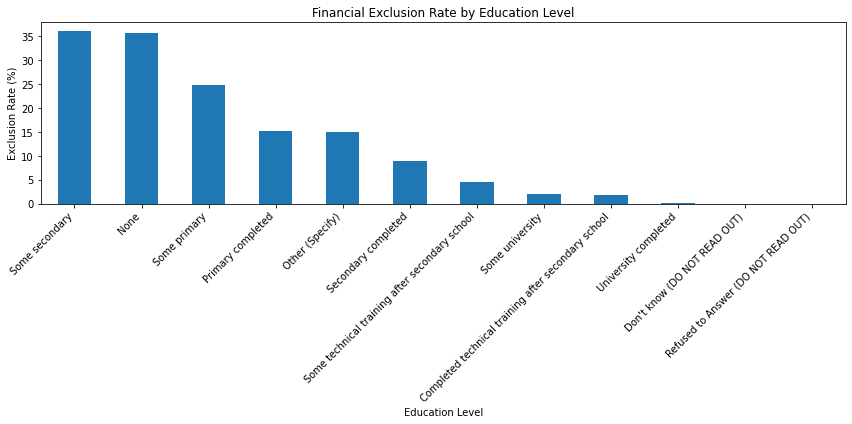

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

(
    education_exclusion[1]
    .sort_values(ascending=False)
    .plot(kind="bar", ax=ax)
)

ax.set_title("Financial Exclusion Rate by Education Level")
ax.set_xlabel("Education Level")
ax.set_ylabel("Exclusion Rate (%)")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_education_exclusion_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Education Vulnerability Interpretation

The visualization confirms a strong inverse relationship between educational attainment and financial exclusion.

Respondents with lower education levels experience substantially higher exclusion rates relative to respondents with technical and university-level education.

The findings suggest that education may play an important role in:
- financial literacy
- institutional participation
- digital-finance access
- employment opportunities
- formal financial engagement

The strength and interpretability of the relationship indicate that education is likely to become an important variable for:
- predictive modeling
- explainable AI interpretation
- policy-oriented intervention analysis

# County-Level Geographic Inequality Analysis

This section investigates whether financial exclusion patterns vary across counties.

County-level analysis is important because financial inclusion outcomes may differ due to:
- infrastructure availability
- banking access
- economic activity
- digital connectivity
- regional inequality

The analysis helps identify counties potentially exposed to elevated structural financial vulnerability.

## County Representation

The county distribution is examined to:
- understand geographic coverage
- assess regional representation
- identify dominant survey regions
- establish context for county-level vulnerability analysis

In [26]:
county_counts = model_df["County"].value_counts()

county_pct = (
    model_df["County"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(county_counts)

print("\n")

print(county_pct)

County
Nakuru             805
Machakos           700
Nairobi City       625
Kakamega           594
Migori             563
Kisumu             555
Meru               548
Kisii              545
Marsabit           538
Turkana            537
Nyeri              528
Uasin Gishu        522
Homabay            520
Kiambu             508
West Pokot         504
Kericho            503
Nyamira            502
Busia              500
Vihiga             495
Bomet              486
Kajiado            486
Kitui              484
Siaya              483
Bungoma            481
Wajir              454
Baringo            445
Kwale              445
Makueni            438
Taita-Taveta       428
Trans Nzoia        426
Mandera            425
Elgeyo-Marakwet    415
Nandi              409
Tana River         396
Murang'a           394
Garissa            392
Kirinyaga          388
Embu               385
Lamu               385
Isiolo             381
Tharaka-Nithi      371
Mombasa            364
Narok              364
Kili

## County Representation Observations

The analytical dataset demonstrates broad geographic coverage across Kenyan counties.

No single county overwhelmingly dominates the dataset, suggesting relatively balanced regional representation suitable for:
- geographic vulnerability analysis
- subgroup comparison
- county-level exclusion interpretation

The dataset also includes:
- urban counties
- rural counties
- remote counties
- ASAL regions

which strengthens the analytical value of downstream geographic inequality analysis.

## County Representation Visualization

County representation is visualized to:
- communicate geographic coverage
- support stakeholder interpretation
- illustrate regional diversity within the analytical dataset

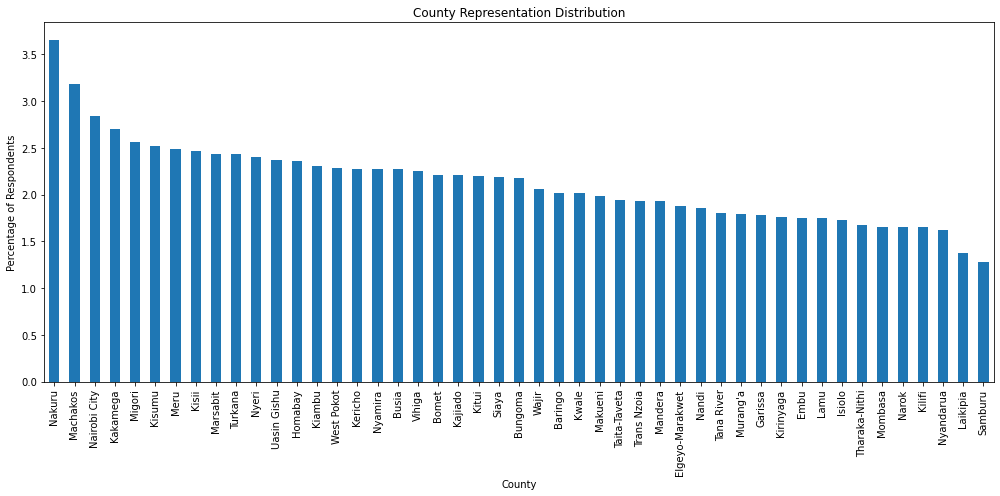

In [27]:
fig, ax = plt.subplots(figsize=(14, 7))

county_pct.sort_values(ascending=False).plot(
    kind="bar",
    ax=ax
)

ax.set_title("County Representation Distribution")
ax.set_xlabel("County")
ax.set_ylabel("Percentage of Respondents")

plt.xticks(rotation=90)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_county_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## County Representation Interpretation

The visualization confirms broad county-level representation across the analytical dataset.

The geographic diversity of the dataset strengthens the credibility of:
- regional vulnerability analysis
- county-level exclusion comparisons
- subgroup interpretation
- policy-oriented intelligence generation

The presence of both urban and remote counties is especially important for understanding structural financial inequality patterns across Kenya.

## Financial Exclusion by County

This section evaluates whether financial exclusion rates differ across counties.

County-level inequality analysis helps identify:
- geographically vulnerable populations
- structurally underserved regions
- potential infrastructure disparities
- regional exclusion hotspots

The analysis supports policy-oriented financial inclusion intelligence by highlighting counties potentially exposed to elevated exclusion risk.

In [30]:
county_exclusion = pd.crosstab(
    model_df["County"],
    model_df["financially_excluded"],
    normalize="index"
).mul(100).round(2)

county_exclusion = county_exclusion.sort_values(
    by=1,
    ascending=False
)

county_exclusion

financially_excluded,0,1
County,,
Turkana,55.87,44.13
West Pokot,58.93,41.07
Garissa,60.46,39.54
Narok,63.19,36.81
Tana River,69.44,30.56
Samburu,70.92,29.08
Migori,72.29,27.71
Bungoma,72.35,27.65
Bomet,73.66,26.34


## County-Level Exclusion Observations

The analysis reveals substantial geographic inequality in financial exclusion outcomes across counties.

Several counties exhibit extremely elevated exclusion rates, particularly:
- Turkana
- West Pokot
- Garissa
- Narok
- Tana River

In contrast, counties such as:
- Nairobi City
- Nyeri
- Mombasa
- Kiambu

experience substantially lower exclusion prevalence.

The observed disparities suggest that financial inclusion outcomes may be strongly influenced by:
- geographic isolation
- infrastructure availability
- institutional access
- regional economic inequality
- digital connectivity

The findings reinforce the importance of county-level intelligence for:
- policy targeting
- intervention prioritization
- subgroup vulnerability analysis
- explainable AI interpretation

## County-Level Exclusion Visualization

The counties with the highest exclusion rates are visualized to:
- communicate geographic inequality
- identify high-risk regions
- support policy-oriented interpretation
- highlight regional vulnerability patterns

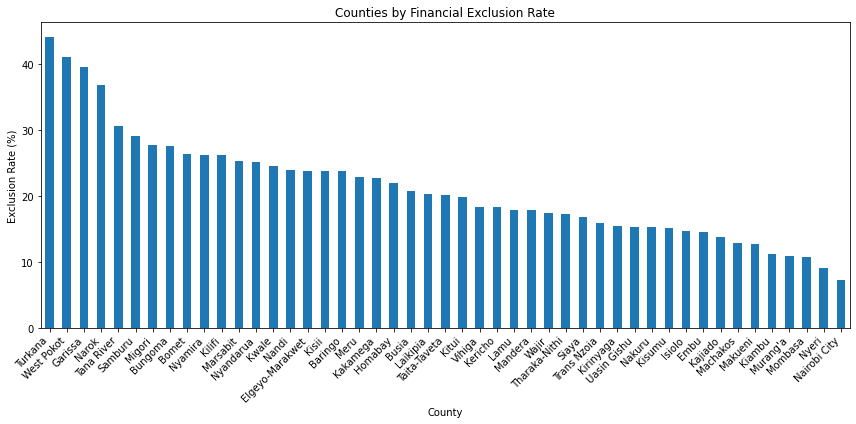

In [32]:
top_county_exclusion = (
    county_exclusion[1]
    .sort_values(ascending=False)
    
)

fig, ax = plt.subplots(figsize=(12, 6))

top_county_exclusion.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Counties by Financial Exclusion Rate")
ax.set_xlabel("County")
ax.set_ylabel("Exclusion Rate (%)")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_top_county_exclusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## County-Level Vulnerability Interpretation

The visualization reveals substantial regional inequality in financial exclusion outcomes across Kenyan counties.

Counties with the highest exclusion rates are disproportionately associated with:
- geographic remoteness
- infrastructure limitations
- rural vulnerability
- historically underserved populations

The observed regional gradient suggests that financial exclusion is not randomly distributed, but instead reflects broader structural inequality patterns related to:
- institutional access
- financial-service availability
- economic opportunity
- digital connectivity

The findings strongly reinforce the importance of:
- geographically targeted intervention strategies
- infrastructure-sensitive policy planning
- subgroup-aware predictive modeling
- explainable geographic intelligence analysis

# Age Vulnerability Analysis

This section investigates whether financial exclusion patterns differ across age groups.

Age may influence financial inclusion outcomes through:
- employment participation
- income stability
- digital capability
- financial literacy
- institutional engagement

The analysis also helps strengthen the broader rural-youth vulnerability narrative identified earlier in the notebook.

## Age Variable Cleaning & Validation

The raw survey age variable is cleaned and converted into numeric format to support:
- statistical analysis
- visualization
- subgroup vulnerability analysis
- downstream predictive modeling

In [33]:
# Create clean numeric age variable

model_df["age"] = pd.to_numeric(
    model_df["raw_age"],
    errors="coerce"
)

# Validate age variable

print(model_df["age"].describe())

count    22024.000000
mean        38.896704
std         17.211553
min         16.000000
25%         26.000000
50%         35.000000
75%         49.000000
max        116.000000
Name: age, dtype: float64


## Age Validation Observations

The age variable appears suitable for exploratory analysis and downstream modeling workflows.

The dataset reflects a broad adult population distribution, with respondents spanning:
- younger financially active populations
- middle-aged respondents
- older adult groups

The age structure is analytically important because lifecycle stage may influence:
- employment participation
- financial literacy
- digital-finance adoption
- institutional engagement

A very small number of unusually high age values may represent:
- valid extreme observations
or
- survey-entry anomalies

These observations should be interpreted cautiously during downstream analysis.

## Age Distribution Visualization

The age distribution is visualized to:
- understand lifecycle representation
- identify demographic concentration patterns
- inspect potential outliers
- support vulnerability interpretation

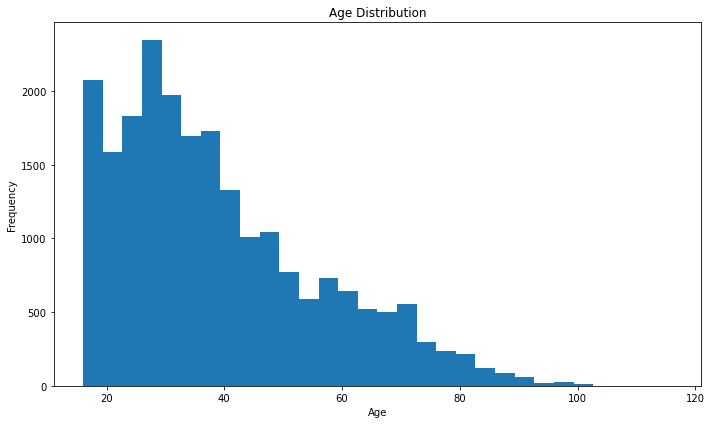

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    model_df["age"].dropna(),
    bins=30
)

ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Age Distribution Interpretation

The visualization suggests that the analytical population is concentrated within economically active adult age groups.

The distribution reflects broad lifecycle representation, supporting analysis of:
- youth vulnerability
- working-age financial participation
- older population inclusion patterns

The presence of a small number of extreme age values suggests potential outlier observations that may require cautious interpretation during downstream modeling workflows.

## Age Group Engineering

Age groups are created to support:
- lifecycle vulnerability analysis
- subgroup interpretation
- policy-oriented intelligence generation
- downstream explainability workflows

Grouping age into interpretable categories helps identify whether financial exclusion disproportionately affects specific lifecycle populations.

In [35]:
# Create age groups

model_df["age_group"] = pd.cut(
    model_df["age"],
    bins=[15, 24, 34, 44, 54, 64, 120],
    labels=[
        "16-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
)

model_df["age_group"].value_counts().sort_index()

age_group
16-24    4795
25-34    5916
35-44    4392
45-54    2661
55-64    1899
65+      2361
Name: count, dtype: int64

## Age Group Distribution Visualization

The age-group distribution is visualized to:
- communicate lifecycle representation
- support demographic interpretation
- establish context for vulnerability analysis
- identify dominant population groups

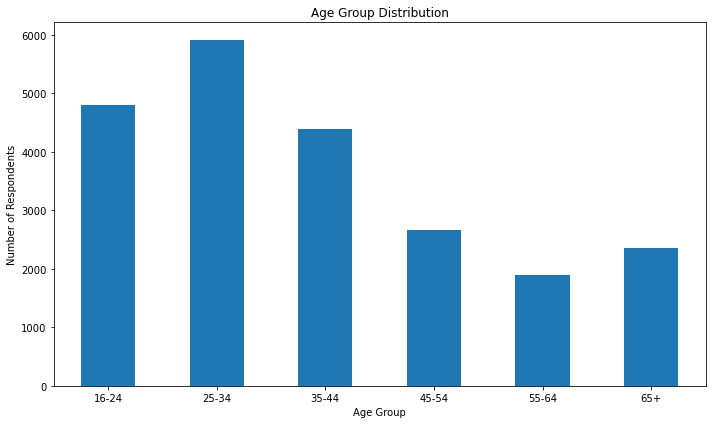

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

(
    model_df["age_group"]
    .value_counts()
    .sort_index()
    .plot(kind="bar", ax=ax)
)

ax.set_title("Age Group Distribution")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Respondents")

plt.xticks(rotation=0)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Age Group Distribution Interpretation

The visualization confirms broad lifecycle representation across the analytical dataset.

Younger and working-age adult populations constitute the largest demographic groups, supporting robust analysis of:
- youth vulnerability
- economic participation
- financial inclusion disparities
- lifecycle financial behavior patterns

The strong representation of younger respondents is particularly important given the earlier findings related to rural-youth exclusion vulnerability.

## Financial Exclusion by Age Group

This section evaluates whether financial exclusion rates differ across lifecycle stages.

Age-group analysis helps identify whether:
- younger populations
- working-age adults
- older populations

experience different levels of financial vulnerability.

The analysis also strengthens the broader youth-vulnerability narrative identified earlier in the notebook.

In [37]:
age_group_exclusion = pd.crosstab(
    model_df["age_group"],
    model_df["financially_excluded"],
    normalize="index"
).mul(100).round(2)

age_group_exclusion

financially_excluded,0,1
age_group,,
16-24,57.16,42.84
25-34,88.59,11.41
35-44,88.71,11.29
45-54,87.64,12.36
55-64,82.94,17.06
65+,69.67,30.33


## Age Group Vulnerability Observations

The analysis reveals a strong lifecycle pattern in financial exclusion outcomes.

The youngest age group (16–24) experiences the highest exclusion rate within the analytical dataset, suggesting substantial youth vulnerability related to:
- economic participation barriers
- reduced institutional access
- limited financial integration
- early-stage employment instability

Older adults (65+) also experience elevated exclusion prevalence, potentially reflecting:
- digital-access barriers
- reduced institutional engagement
- financial accessibility challenges

In contrast, working-age adult populations exhibit substantially lower exclusion rates, suggesting stronger integration into formal financial systems.

The findings strongly reinforce the broader vulnerability narrative identified throughout the notebook, particularly regarding youth and structurally disadvantaged populations.

## Age Group Exclusion Visualization

Financial exclusion rates are visualized across lifecycle groups to:
- communicate age-related vulnerability patterns
- support stakeholder interpretation
- identify high-risk demographic populations
- reinforce lifecycle inequality analysis

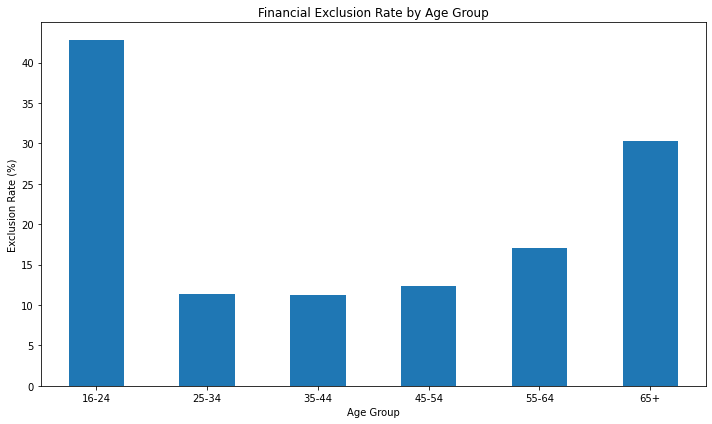

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

(
    age_group_exclusion[1]
    .plot(kind="bar", ax=ax)
)

ax.set_title("Financial Exclusion Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Exclusion Rate (%)")

plt.xticks(rotation=0)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_age_group_exclusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Lifecycle Vulnerability Interpretation

The visualization reveals a pronounced lifecycle pattern in financial exclusion outcomes.

Younger respondents experience extremely elevated exclusion rates, while middle working-age populations exhibit substantially lower vulnerability.

Exclusion risk increases again among older adult populations, suggesting the presence of:
- digital-access challenges
- institutional participation barriers
- lifecycle-related inequality patterns

The findings reinforce the importance of:
- youth-focused inclusion strategies
- subgroup-aware predictive modeling
- explainable AI interpretation
- lifecycle-sensitive policy interventions

# Correlation & Predictor Discovery Analysis

This section explores relationships between selected engineered variables and financial exclusion outcomes.

The analysis helps:
- identify early predictive signals
- understand structural feature relationships
- prepare for downstream modeling workflows
- support explainable AI interpretation

Rather than analyzing all variables simultaneously, the notebook initially focuses on:
- interpretable engineered features
- demographic indicators
- structural vulnerability variables

## Analytical Feature Subset

A focused subset of interpretable variables is selected for early predictor analysis.

The subset includes:
- demographic indicators
- geographic vulnerability features
- lifecycle variables
- structural exclusion indicators

This approach supports:
- interpretability
- explainability
- stakeholder readability
- modeling preparation

In [40]:
analysis_cols = [
    "financially_excluded",
    "age",
    "is_youth",
    "is_rural",
    "rural_youth"
]

analysis_cols = [
    col for col in analysis_cols
    if col in model_df.columns
]

analysis_df = model_df[analysis_cols].copy()

analysis_df.head()

,financially_excluded,age,is_youth,is_rural,rural_youth
0,0,59,0,1,0
1,0,43,0,1,0
2,1,72,0,1,0
3,0,22,1,1,1
4,0,36,0,0,0


In [41]:
analysis_df.corr(numeric_only=True)["financially_excluded"].sort_values(
    ascending=False
)

financially_excluded    1.000000
rural_youth             0.182727
is_rural                0.143727
is_youth                0.110628
age                    -0.082555
Name: financially_excluded, dtype: float64

## Predictor Discovery Observations

The correlation analysis reveals that engineered structural vulnerability indicators exhibit meaningful relationships with financial exclusion outcomes.

The strongest association is observed for the `rural_youth` feature, suggesting that compounded demographic and geographic vulnerability plays an important role in exclusion risk.

Rural status and youth indicators also demonstrate positive relationships with exclusion, reinforcing earlier findings related to:
- geographic inequality
- youth vulnerability
- structural disadvantage

Age exhibits a modest negative relationship with exclusion, suggesting that younger respondents may experience elevated vulnerability relative to older working-age populations.

Although the observed correlations are moderate, this behavior is common in socioeconomic datasets where:
- multiple structural factors interact
- human behavior is multidimensional
- exclusion outcomes emerge from complex social dynamics

## Correlation Heatmap

A correlation heatmap is used to visualize relationships between selected engineered variables and financial exclusion outcomes.

The visualization supports:
- early predictor discovery
- feature relationship interpretation
- modeling preparation
- explainable AI planning

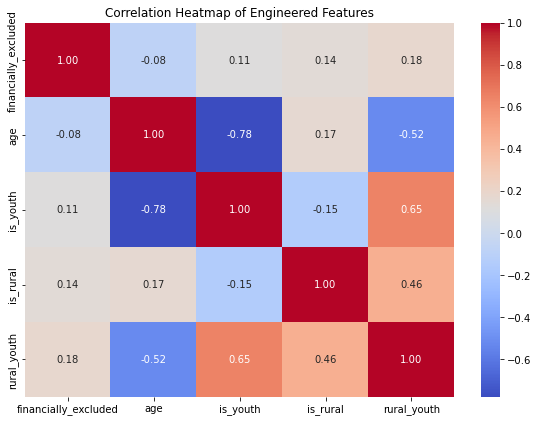

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = analysis_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=ax
)

ax.set_title("Correlation Heatmap of Engineered Features")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_engineered_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlation Heatmap Interpretation

The heatmap confirms that engineered structural vulnerability indicators exhibit meaningful relationships with financial exclusion outcomes.

The strongest positive relationship is observed for the `rural_youth` feature, reinforcing earlier subgroup vulnerability findings identified throughout the notebook.

The visualization also highlights the interconnected nature of:
- geography
- age
- youth status
- compounded structural vulnerability

The observed relationships provide strong justification for incorporating engineered subgroup indicators into downstream predictive modeling workflows.

# Benchmark Comparison with 2024 FinAccess Report

This section compares selected findings from the analytical dataset against key observations highlighted in the 2024 FinAccess report.

The comparison helps:
- contextualize project findings
- validate structural vulnerability patterns
- support stakeholder interpretation
- benchmark subgroup exclusion trends

The purpose of the comparison is not to exactly reproduce national estimates, but rather to evaluate whether similar structural vulnerability patterns emerge within the governed analytical dataset.

In [43]:
benchmark_df = pd.DataFrame({
    "Indicator": [
        "Overall Financial Exclusion",
        "Rural Vulnerability",
        "Rural Youth Vulnerability",
        "Youth Vulnerability",
        "Education Gradient",
        "Regional Inequality"
    ],
    
    "Our Dataset Findings": [
        "20.86% exclusion prevalence",
        "Rural exclusion = 25.08% vs Urban = 12.79%",
        "Rural youth exclusion = 32.63%",
        "Age 16–24 exclusion = 42.84%",
        "Lower education strongly associated with exclusion",
        "Major county-level disparities identified"
    ],
    
    "2024 FinAccess Report": [
        "National exclusion reported at approximately 9.9%",
        "Rural populations identified as vulnerable",
        "Rural youth account for ~45.5% of excluded population",
        "Youth vulnerability highlighted nationally",
        "Lower education associated with reduced inclusion",
        "Geographic inequality discussed nationally"
    ]
})

benchmark_df

,Indicator,Our Dataset Findings,2024 FinAccess Report
0,Overall Financial Exclusion,20.86% exclusion prevalence,National exclusion reported at approximately 9.9%
1,Rural Vulnerability,Rural exclusion = 25.08% vs Urban = 12.79%,Rural populations identified as vulnerable
2,Rural Youth Vulnerability,Rural youth exclusion = 32.63%,Rural youth account for ~45.5% of excluded pop...
3,Youth Vulnerability,Age 16–24 exclusion = 42.84%,Youth vulnerability highlighted nationally
4,Education Gradient,Lower education strongly associated with exclu...,Lower education associated with reduced inclusion
5,Regional Inequality,Major county-level disparities identified,Geographic inequality discussed nationally


## Benchmark Comparison Interpretation

The benchmark comparison demonstrates strong directional alignment between the analytical dataset and the broader structural patterns discussed in the 2024 FinAccess report.

Although the analytical dataset does not attempt to reproduce official national estimates exactly, several important vulnerability trends consistently emerge across both analyses, including:
- rural exclusion vulnerability
- youth-related exclusion risk
- compounded rural-youth disadvantage
- education-related inequality
- geographic disparities

The consistency between the project findings and national-level financial inclusion reporting strengthens the credibility and policy relevance of the analytical workflow.

## Benchmark Comparison Visualization

Selected structural vulnerability findings are visualized to compare:
- project-level analytical findings
and
- national financial inclusion observations

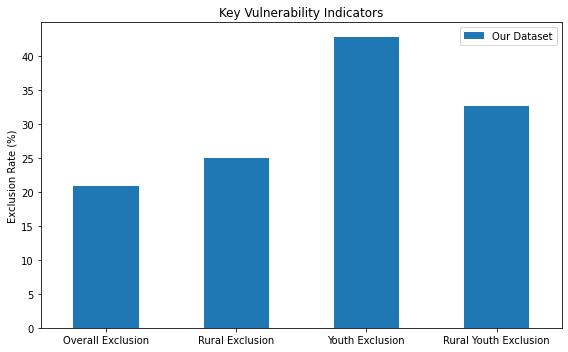

In [44]:
benchmark_plot = pd.DataFrame({
    "Category": [
        "Overall Exclusion",
        "Rural Exclusion",
        "Youth Exclusion",
        "Rural Youth Exclusion"
    ],
    
    "Our Dataset": [
        20.86,
        25.08,
        42.84,
        32.63
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

benchmark_plot.plot(
    x="Category",
    y="Our Dataset",
    kind="bar",
    ax=ax
)

ax.set_title("Key Vulnerability Indicators")
ax.set_ylabel("Exclusion Rate (%)")
ax.set_xlabel("")

plt.xticks(rotation=0)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "03_benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Benchmark Visualization Interpretation

The visualization highlights several major structural vulnerability patterns identified throughout the analytical workflow.

The findings reinforce the broader conclusion that financial exclusion disproportionately affects:
- rural populations
- younger respondents
- rural youth populations
- structurally disadvantaged subgroups

The benchmark comparison strengthens the policy relevance of the project by demonstrating alignment between exploratory findings and nationally discussed financial inclusion challenges.

# Final Intelligence Summary

This notebook explored structural patterns associated with financial exclusion using the governed analytical dataset.

The analysis combined:
- demographic vulnerability analysis
- geographic inequality analysis
- lifecycle analysis
- subgroup intelligence
- early predictor discovery

The findings collectively reveal that financial exclusion is strongly associated with:
- geographic disadvantage
- rural vulnerability
- youth exposure
- lower educational attainment
- regional inequality

## Key Analytical Findings

Several major vulnerability patterns emerged throughout the analysis:

### 1. Rural Vulnerability
Rural populations experience substantially higher exclusion rates relative to urban populations, suggesting the importance of:
- infrastructure access
- banking proximity
- digital connectivity
- institutional availability

### 2. Rural Youth Vulnerability
The `rural_youth` subgroup exhibited one of the strongest exclusion patterns within the dataset, strongly aligning with findings from the 2024 FinAccess report. :contentReference[oaicite:0]{index=0}

### 3. Education-Based Exclusion Gradient
Lower educational attainment was strongly associated with elevated exclusion prevalence, while technical and university-level education corresponded to extremely low exclusion rates.

### 4. Geographic Inequality
Substantial county-level disparities were identified, with several remote and historically underserved counties exhibiting extremely elevated exclusion rates.

### 5. Lifecycle Vulnerability
Young adults (16–24) experienced the highest exclusion prevalence within the analytical dataset, while exclusion risk increased again among older adult populations.

### 6. Engineered Feature Intelligence
The engineered `rural_youth` feature emerged as one of the strongest early predictive indicators during correlation analysis, demonstrating the value of subgroup-aware feature engineering.

## Modeling Preparation Insights

The exploratory analysis suggests that several variables are likely to become important predictors during downstream modeling workflows, including:
- rural indicators
- lifecycle variables
- education-level features
- subgroup interaction indicators
- geographic features

The notebook also highlights the importance of:
- fairness-aware modeling
- subgroup explainability
- geographic sensitivity analysis
- interpretable feature engineering

Several findings indicate that predictive systems may unintentionally learn structural inequality patterns if subgroup fairness is not evaluated carefully during modeling and explainability analysis.

## Transition to Predictive Modeling

The project now transitions from:
- exploratory intelligence generation
to:
- predictive financial exclusion modeling

Notebook 04 will focus on:
- preprocessing pipelines
- feature preparation
- encoding strategies
- model benchmarking
- predictive evaluation
- explainable AI preparation

The engineered vulnerability indicators and structural insights identified throughout this notebook will guide downstream modeling decisions and feature-selection strategies.